## 1) Setup

In [2]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)

## 2) The scenario

You're a data scientist at a college-prep company.

You ran a new math tutoring program and sampled **12 students**.

The national benchmark mean is **50**.

Your sample looks great... but something is off.

In [3]:
benchmark = 50

scores = [54, 55, 52, 53, 56, 54, 55, 53, 52, 54, 56, 95]

df = pd.DataFrame({"student_id": range(1, 13), "math_score": scores})
df

,student_id,math_score
0,1,54
1,2,55
2,3,52
3,4,53
4,5,56
5,6,54
6,7,55
7,8,53
8,9,52
9,10,54


Look at the last student.

Before computing anything:

* What do you think the mean will be?
* What about the median?
* If you removed that last student, would your answer change?

In [4]:
df["math_score"].describe()

count    12.000000
mean     57.416667
std      11.912242
min      52.000000
25%      53.000000
50%      54.000000
75%      55.250000
max      95.000000
Name: math_score, dtype: float64

In [5]:
df["math_score"].agg(
    ["count", "mean", "median", "std"]
    )

count     12.000000
mean      57.416667
median    54.000000
std       11.912242
Name: math_score, dtype: float64

The mean is pulled up by that 95.

The median barely moves.

Let's see it:

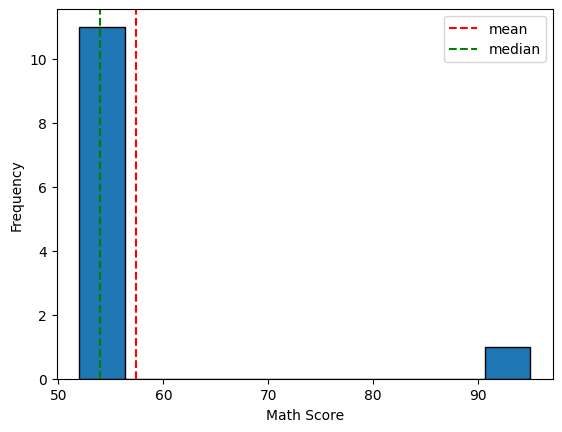

In [6]:
plt.hist(df["math_score"], bins=10, edgecolor="black")
plt.axvline(df["math_score"].mean(), color="red", ls="--", label="mean")
plt.axvline(df["math_score"].median(), color="green", ls="--", label="median")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()


One data point out of 12 is roughly 8% of the data.

With small samples, every point has outsized influence on the mean.

The median is resistant — it only cares about rank order, not magnitude.

## 3) Population vs sample

Before going further, let's be precise about what we're doing.

| | Population | Sample |
|---|---|---|
| What | All students who could take the program | The 12 we observed |
| Size | Unknown, very large | n = 12 |
| Mean | $\mu$ (unknown parameter) | $\bar{x}$ (computed statistic) |
| Std dev | $\sigma$ (unknown parameter) | $s$ (computed statistic) |

We never see $\mu$.

We compute $\bar{x}$ and use it to **estimate** $\mu$.

The rest of this notebook is about how uncertain that estimate is.

## 4) Two analysts, two conclusions



In [7]:
df['math_score']

0     54
1     55
2     52
3     53
4     56
5     54
6     55
7     53
8     52
9     54
10    56
11    95
Name: math_score, dtype: int64

In [8]:
A = []
for i in df.itertuples():
    if i.math_score < 55:
        A.append(True)
    else:
        A.append(False)
A

[True, False, True, True, False, True, False, True, True, True, False, False]

In [9]:
df['math_score'] < 55

0      True
1     False
2      True
3      True
4     False
5      True
6     False
7      True
8      True
9      True
10    False
11    False
Name: math_score, dtype: bool

In [10]:
# Method 1 of filtering: Using boolean indexing
mask = df['math_score'] < 55

# Applies the mask to the DataFrame, returning only rows where the condition is True
df[mask]

,student_id,math_score
0,1,54
2,3,52
3,4,53
5,6,54
7,8,53
8,9,52
9,10,54


In [11]:
# Method 2 of filtering: Using the query method
THRESHOLD = 55
df.query("math_score < @THRESHOLD")

,student_id,math_score
0,1,54
2,3,52
3,4,53
5,6,54
7,8,53
8,9,52
9,10,54


In [12]:
#NOTE: This will RETURN a temporary view
# This is NOT APPLIED "IN PLACE" to the original DataFrame
df[df["math_score"] < 55]

,student_id,math_score
0,1,54
2,3,52
3,4,53
5,6,54
7,8,53
8,9,52
9,10,54


In [13]:
# AS SEEN HERE THE DF IS UNCHANGED, THE FILTERING IS NOT APPLIED IN PLACE
df

,student_id,math_score
0,1,54
1,2,55
2,3,52
3,4,53
4,5,56
5,6,54
6,7,55
7,8,53
8,9,52
9,10,54


In [14]:
# remove the outlier
df_no_outlier = df[df["math_score"] < 90].copy()

In [15]:
df

,student_id,math_score
0,1,54
1,2,55
2,3,52
3,4,53
4,5,56
5,6,54
6,7,55
7,8,53
8,9,52
9,10,54


In [16]:
df_no_outlier

,student_id,math_score
0,1,54
1,2,55
2,3,52
3,4,53
4,5,56
5,6,54
6,7,55
7,8,53
8,9,52
9,10,54


In [17]:
# mean with vs without the outlier
df["math_score"].mean()

np.float64(57.416666666666664)

In [18]:
df_no_outlier["math_score"].mean()

np.float64(54.0)

In [19]:
# median with vs without
# as you can see it didn't change!
df["math_score"].median(), df_no_outlier["math_score"].median()

(np.float64(54.0), np.float64(54.0))

Analyst A uses the mean: "Score is 57.4, well above 50. Ship it!"

Analyst B uses the median: "Score is 54.0, barely above 50. Hold on."

Same data. Different conclusions.

Removing one data point changed the mean by several points.

The median barely moved.

| Statistic | Robust to outliers? | When to prefer |
|-----------|:---:|---|
| Mean | No | Symmetric distributions, large n |
| Median | Yes | Skewed data, small n, outliers present |

This motivates the question: **how variable is our estimate?**

## 5) Sampling distribution — the key idea

If we sampled 12 *different* students, would we get the same mean?

No. Every sample gives a slightly different $\bar{x}$.

The distribution of all those possible $\bar{x}$ values is the **sampling distribution of the mean**.

Let's simulate it.

We'll create a fake population (in reality we'd never see this), then repeatedly draw samples.

In [20]:
# simulated population: mostly normal, with some rare extreme scores
N = 20000
pop = np.random.normal(54, 8.5, size=N)
pd.Series(pop).describe()


count    20000.000000
mean        53.930438
std          8.408146
min         22.792754
25%         48.310140
50%         53.992008
75%         59.585461
max         86.739878
dtype: float64

Text(0.5, 1.0, 'Simulated Population Distribution (without outliers)')

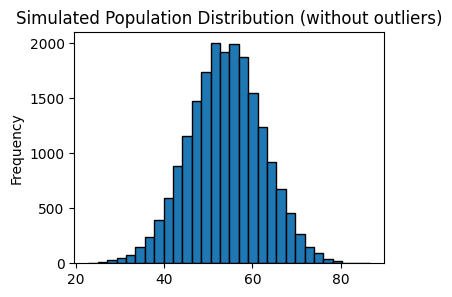

In [21]:
ax = pd.Series(pop).plot.hist(
    bins=30, 
    edgecolor="black", 
    figsize=(4,3)
    )
ax.set_title("Simulated Population Distribution (without outliers)")

In [22]:
range(N)

range(0, 20000)

In [23]:
# Method 1 of returning an np array of size 20000
np.array(range(N))

array([    0,     1,     2, ..., 19997, 19998, 19999], shape=(20000,))

In [24]:
# Method 2 of returning an np array of size 20000
np.arange(N)

array([    0,     1,     2, ..., 19997, 19998, 19999], shape=(20000,))

In [25]:

# inject rare high outliers
outlier_idx = np.random.choice(
    np.arange(N),
    size=300, 
    replace=False
    )

len(outlier_idx)

300

In [26]:
type(pop)

numpy.ndarray

Q2.1 
Observed: 
- This 

In [27]:
# this returns the 2nd element of the population array, which is a normal score without outliers
pop[1]

np.float64(50.03953235040292)

In [28]:
len(pop)

20000

In [29]:
ids = [1,3,5,7,10,19999]
pop[ids]

array([50.03953235, 57.46388841, 54.01755737, 39.0848434 , 48.68385372,
       51.11989146])

In [30]:
pop[[1,3,5,7,10]] 

array([50.03953235, 57.46388841, 54.01755737, 39.0848434 , 48.68385372])

In [31]:
# This is overwriting the original values at those indices with new values that are 100 points higher
pop[[1,3,5,7,10]] = pop[[1,3,5,7,10]] + 100

In [32]:
# Now the populuation array object has updated values at ID: 1,3,5,7,10
# Note: the `:10` syntax is a slicing operation that returns the first 10 elements
pop[:10]

array([ 68.36946848, 150.03953235,  54.27897139, 157.46388841,
        47.29415426, 154.01755737,  53.99243172, 139.0848434 ,
        62.65009305,  59.10423739])

In [33]:

# the outliers will have a bias or anomoly of +40, meaning they will be around 94 instead of 54
pop[outlier_idx] = pop[outlier_idx] + 40

In [34]:

pop = pd.Series(pop)
pop.describe()

count    20000.000000
mean        54.555438
std          9.810174
min         22.792754
25%         48.401357
50%         54.164534
75%         59.893722
max        157.463888
dtype: float64

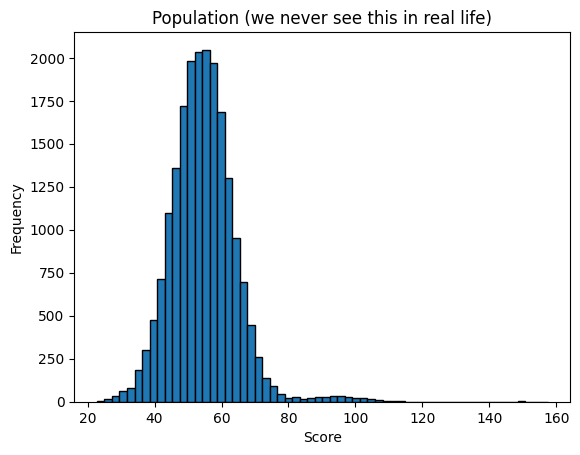

In [35]:
pop.plot(kind="hist", bins=60, edgecolor="black")
plt.title("Population (we never see this in real life)")
plt.xlabel("Score")
plt.show()

Now draw many samples of size 12 and compute the mean each time:

In [36]:
def sample_mean(population, n):
    return np.mean(np.random.choice(population, size=n, replace=False))

In [37]:
# one sample mean
sample_mean(pop, 12)

np.float64(51.66079479476675)

In [38]:
# now repeat 5000 times
means = pd.Series([sample_mean(pop, n=12) for _ in range(5000)])
means.describe()

count    5000.000000
mean       54.575750
std         2.822709
min        44.855493
25%        52.650772
50%        54.426259
75%        56.373223
max        65.975662
dtype: float64

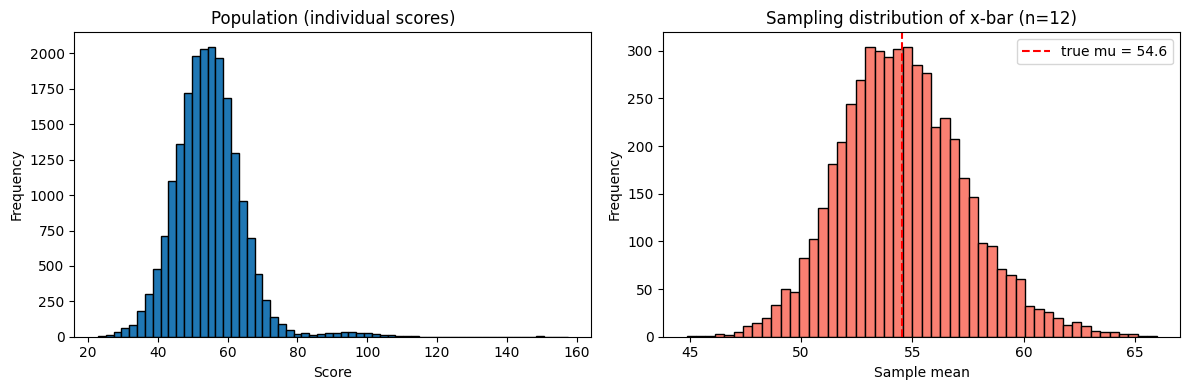

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pop.plot(kind="hist", bins=60, ax=axes[0], edgecolor="black")
axes[0].set_title("Population (individual scores)")
axes[0].set_xlabel("Score")

means.plot(kind="hist", bins=50, ax=axes[1], edgecolor="black", color="salmon")
axes[1].axvline(pop.mean(), color="red", ls="--", label=f"true mu = {pop.mean():.1f}")
axes[1].set_title("Sampling distribution of x-bar (n=12)")
axes[1].set_xlabel("Sample mean")
axes[1].legend()

plt.tight_layout()
plt.show()

You should see:

* the population is wide and right-skewed
* the sampling distribution is narrower and more symmetric

That narrowing is the entire foundation of inference.

This is the **Central Limit Theorem**:

$$\bar{X} \;\dot\sim\; N\!\left(\mu,\; \frac{\sigma^2}{n}\right)$$



In English:

* the sampling distribution of $\bar{x}$ is approximately normal **(even if the population isn't)**
* it's centered at the true $\mu$
* its spread is $\sigma / \sqrt{n}$

## 6) Standard error — the precision lever

Up to now we have seen something unsettling:

If we repeatedly sample 12 students, the mean changes every time.

So the mean is not a fixed number — it is a **random quantity**.

Those possible means form the *sampling distribution*.

The question becomes:

> How unstable is our estimate?

The answer is the **standard error (SE)**.

$$SE = \frac{\sigma}{\sqrt{n}}$$

It measures the typical amount the sample mean moves purely due to random sampling.

### Why SE matters

Think of SE as the **noise level of the estimate**.

- Standard deviation → variability of *individuals*
- Standard error → variability of the *average*

So instead of reporting a single value:

```
mean = 54
```

we acknowledge uncertainty:

```
mean ≈ 54 ± sampling noise
```

### Empirical verification

We can check SE because in simulation we *do* know the population.

If the formula is right, the theoretical SE should match the actual spread of our 5,000 simulated means.

In [40]:
# empirical SE — the actual spread of our simulated means
se_empirical = means.std()

# theoretical SE — predicted by the formula
sigma_pop = pop.std()
se_theory = sigma_pop / np.sqrt(12)

print(f"Population sigma:   {sigma_pop:.2f}")
print(f"Theoretical SE:     {se_theory:.2f}")
print(f"Empirical SE:       {se_empirical:.2f}")

Population sigma:   9.81
Theoretical SE:     2.83
Empirical SE:       2.82


They match.

The formula really predicts how much sample means fluctuate.

### What happens when n changes?

SE shrinks like $1/\sqrt{n}$.

To **halve** the uncertainty, you need **4× the data**.

Let's see it:

In [41]:
def sampling_dist(population, n, reps=3000):
    return pd.Series([sample_mean(population, n) for _ in range(reps)])

In [42]:
results = []
for n in [5, 12, 30, 100]:
    m = sampling_dist(pop, n)
    results.append({"n": n,
                    "empirical SE": round(m.std(), 2),
                    "theoretical SE": round(sigma_pop / np.sqrt(n), 2)})

pd.DataFrame(results)

,n,empirical SE,theoretical SE
0,5,4.43,4.39
1,12,2.80,2.83
2,30,1.82,1.79
3,100,0.98,0.98


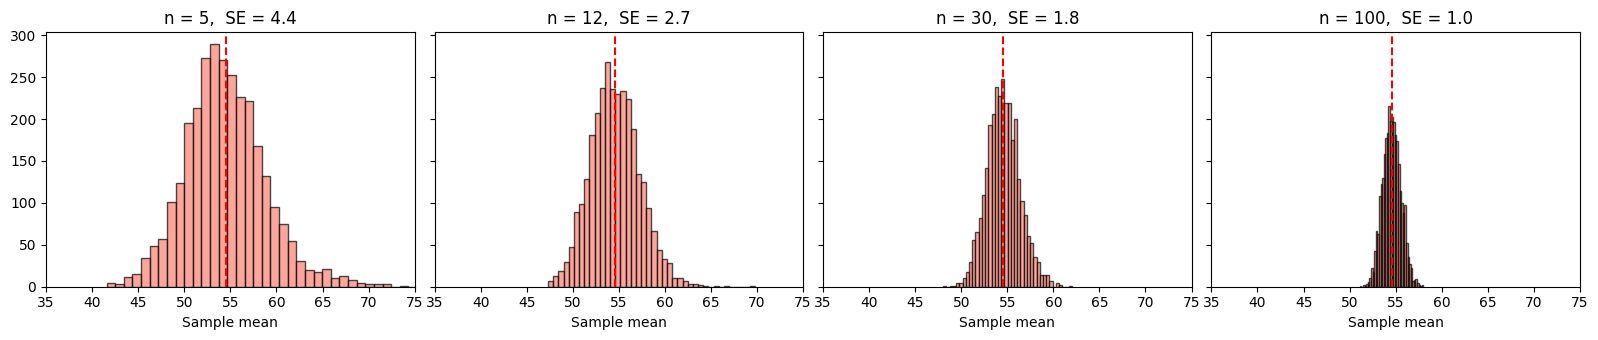

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, n in zip(axes, [5, 12, 30, 100]):
    m = sampling_dist(pop, n)
    ax.hist(m, bins=40, edgecolor="black", color="salmon", alpha=0.7)
    ax.axvline(pop.mean(), color="red", ls="--")
    ax.set_title(f"n = {n},  SE = {m.std():.1f}")
    ax.set_xlabel("Sample mean")
    ax.set_xlim(35, 75)

plt.tight_layout()
plt.show()

The distributions get tighter as n grows.

This is why n = 12 should make you nervous.

In [55]:
import seaborn as sns
df = sns.load_dataset('titanic')


In [56]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [57]:
from matplotlib import pyplot as plt

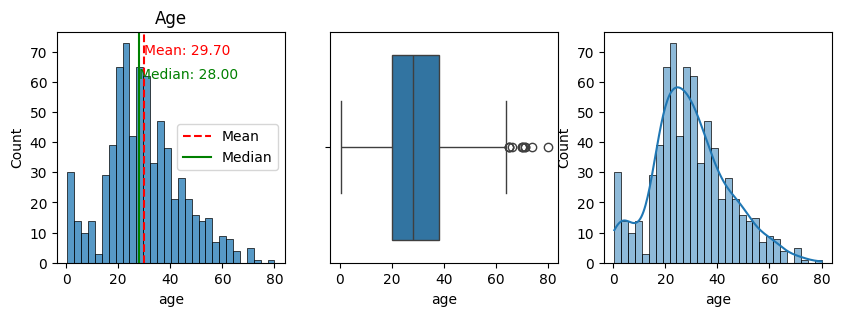

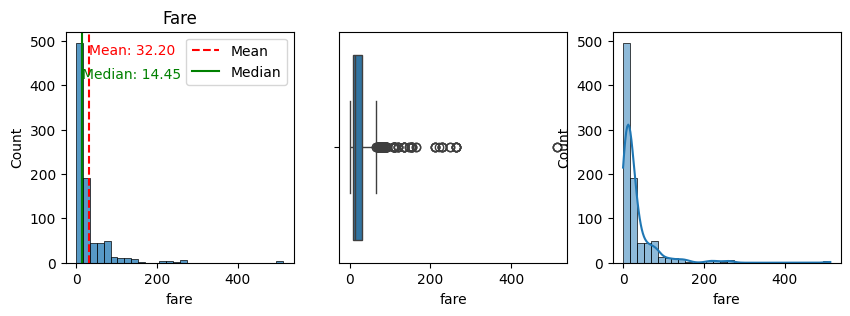

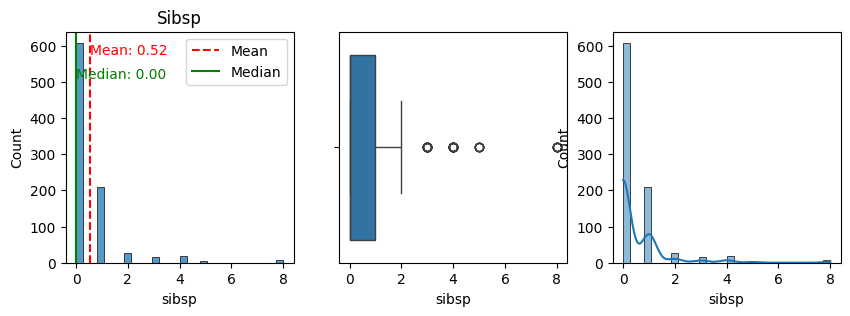

In [58]:
cols = ['age', 'fare', 'sibsp']

# plt the mean and median as vertical lines on the histogram of age, fare, and sibsp
# add the text to the plot figure to indicate the mean and median values

for col in cols:

    fig ,axes = plt.subplots(1,3, figsize=(10, 3))

    # This plots the histogram with a kernel density estimate (kde) overlay for the specified column in the DataFrame
    sns.histplot(data=df, x=col, bins=30, ax=axes[0], kde=False)
    sns.boxplot(data=df, x=col, ax=axes[1])
    sns.histplot(data=df, x=col, bins=30, ax=axes[2], kde=True)

    # This adds vertical lines to the plot to indicate the mean and median values of the column
    axes[0].axvline(df[col].mean(), color='r', linestyle='--', label='Mean')
    axes[0].axvline(df[col].median(), color='g', linestyle='-', label='Median')
    
    # This adds text annotations to the plot to show the mean and median values
    axes[0].text(df[col].mean(), axes[0].get_ylim()[1]*0.9, f'Mean: {df[col].mean():.2f}', color='r')
    axes[0].text(df[col].median(), axes[0].get_ylim()[1]*0.8, f'Median: {df[col].median():.2f}', color='g')

    axes[0].set_title(f'{col.capitalize()}')
    axes[0].legend()


In [59]:
def find_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    return iqr

In [60]:
def get_outlier_zscore(data, z = 3):
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    z_scores = (data - mean) / std
    outliers = np.where(np.abs(z_scores) > z)
    return outliers

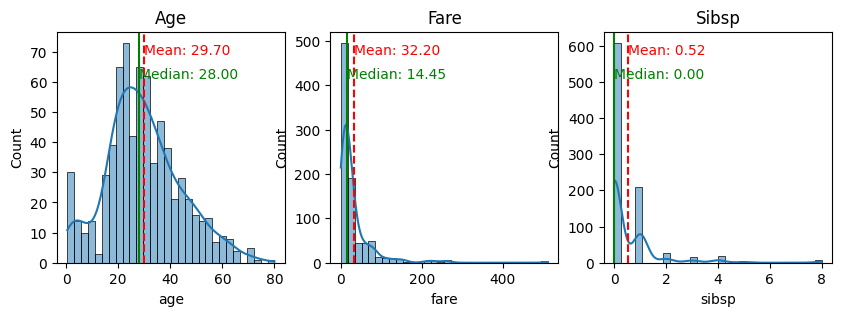

In [61]:
cols = ['age', 'fare', 'sibsp']

# plt the mean and median as vertical lines on the histogram of age, fare, and sibsp
# add the text to the plot figure to indicate the mean and median values
fig ,axes = plt.subplots(1,3, figsize=(10, 3))

for col, ax in zip(cols, axes):

    # This plots the histogram with a kernel density estimate (kde) overlay for the specified column in the DataFrame
    sns.histplot(data=df, x=col, bins=30, ax=ax, kde=True)

    # This adds vertical lines to the plot to indicate the mean and median values of the column
    ax.axvline(df[col].mean(), color='r', linestyle='--', label='Mean')
    ax.axvline(df[col].median(), color='g', linestyle='-', label='Median')
    
    # This adds text annotations to the plot to show the mean and median values
    ax.text(df[col].mean(), ax.get_ylim()[1]*0.9, f'Mean: {df[col].mean():.2f}', color='r')
    ax.text(df[col].median(), ax.get_ylim()[1]*0.8, f'Median: {df[col].median():.2f}', color='g')
    ax.set_title(f'{col.capitalize()}')
    


The fare value is typically 14.45, as it's the median value (note there are outliers which the median is not sensitive to)

In [62]:
# filter for only numerical
df.select_dtypes(include=['float64', 'int64']).corr()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [63]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [64]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object